In [25]:
# STEP 1: Install required libraries
!pip install -q kagglehub opencv-python-headless

# STEP 2: Import required libraries
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import kagglehub

# STEP 3: Download dataset from Kaggle
path = kagglehub.dataset_download("vasukipatel/face-recognition-dataset", force_download=True)
print("Dataset downloaded at:", path)

# STEP 4: Define dataset paths
dataset_path = os.path.join(path, "Faces", "Faces")
csv_path = os.path.join(path, "Dataset.csv")

# STEP 5: Load CSV file
df = pd.read_csv(csv_path)
df["file_path"] = df["id"].apply(lambda x: os.path.join(dataset_path, x))

# STEP 6: Load OpenCV face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# STEP 7: Function to detect faces and preprocess
def load_faces_and_labels(dataframe):
    images, labels = [], []
    label_map = {name: idx for idx, name in enumerate(sorted(dataframe["label"].unique()))}

    for _, row in dataframe.iterrows():
        img_path, label = row["file_path"], row["label"]
        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        faces = face_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5)
        if len(faces) == 0:
            continue

        x, y, w, h = faces[0]
        face = img[y:y+h, x:x+w]
        face = cv2.resize(face, (100, 100))
        images.append(face)
        labels.append(label_map[label])

    if len(images) == 0:
        raise ValueError("No valid face images found!")

    return np.array(images), np.array(labels), label_map

# STEP 8: Load dataset
X, y, label_map = load_faces_and_labels(df)

# STEP 9: Normalize and reshape
X = X.reshape(-1, 100, 100, 1) / 255.0
y = to_categorical(y, num_classes=len(label_map))

# STEP 10: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 11: Define CNN Model (Improved Architecture)
def create_cnn_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 1)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(label_map), activation='softmax')
    ])
    return model

# STEP 12: Compile and train model
model = create_cnn_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# STEP 13: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# STEP 14: Save model
model.save("face_recognition_model.h5")
print("Model saved as face_recognition_model.h5")


Dataset downloaded at: /kaggle/input/face-recognition-dataset
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 35s 920ms/step - accuracy: 0.0341 - loss: 5.2419 - val_accuracy: 0.0266 - val_loss: 7.5818
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 863ms/step - accuracy: 0.0674 - loss: 3.3956 - val_accuracy: 0.0266 - val_loss: 13.2111
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.0744 - loss: 3.4246 - val_accuracy: 0.0190 - val_loss: 12.7491
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 35s 863ms/step - accuracy: 0.0709 - loss: 3.2992 - val_accuracy: 0.0304 - val_loss: 12.6734
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 889ms/step - accuracy: 0.0913 - loss: 3.3113 - val_accuracy: 0.0266 - val_loss: 16.7910
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 897ms/step - accuracy: 0.1002 - loss: 3.3165 - val_accuracy: 0.0266 - val_loss: 11.8608
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 914ms/step - accuracy: 0.1229 - loss: 3.2153 - val_accuracy: 0.0342 - val_loss: 10.9440
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 876ms/step - accuracy: 0.1441 - loss: 3.0927 - val_accuracy: 0.

Test Accuracy: 4.18%
Model saved as face_recognition_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Predicted Person: Unknown


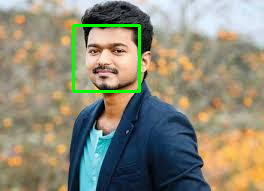

In [28]:
import cv2
import numpy as np
import tensorflow as tf
from google.colab.patches import cv2_imshow  # Import cv2_imshow for Colab

# Load the trained model
model = tf.keras.models.load_model("face_recognition_model.h5")

# Load face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Provide path to the test image
test_image_path = "/content/VIJAY.jpeg"  # 🔁 Change this path to your test image

# Load and preprocess the image
img = cv2.imread(test_image_path)
if img is None:
    raise ValueError("Image not found or unreadable!")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
if len(faces) == 0:
    raise ValueError("No face detected in the image!")

# Draw bounding box around the face
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green bounding box

# Crop the face region and preprocess for prediction
face = gray[y:y+h, x:x+w]
face = cv2.resize(face, (100, 100))
face = face.reshape(1, 100, 100, 1) / 255.0

# Predict
prediction = model.predict(face)
predicted_class = np.argmax(prediction)

# Map class index to label (you must use the same label_map used during training)
label_map_inverse = {0: 'Name1', 1: 'Name2', 2: 'Name3'}  # 🔁 Update this based on your label_map

predicted_name = label_map_inverse.get(predicted_class, "Unknown")
print("Predicted Person:", predicted_name)

# Display the image with bounding box using cv2_imshow
cv2_imshow(img)
